# Lezione 7 — Forecasting
## Da STL e ARIMA alle LSTM, con cenno ai dati sintetici (CTGAN)

### Obiettivi della lezione
1. leggere una serie temporale e riconoscerne la struttura  
2. usare **STL** per scomporre la serie  
3. costruire un modello classico con **ARIMA**  
4. usare un modello additivo come **Prophet**  
5. trasformare la serie in un problema supervisionato con **lag features** e regressione  
6. introdurre un modello deep learning sequenziale con **LSTM**  
7. chiudere con un accenno alla **generazione di dati sintetici** tramite **CTGAN**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
pd.set_option("display.max_columns", 50)


# 1) Introduzione alle serie temporali

Una **serie temporale** è una sequenza ordinata di osservazioni nel tempo.

## Componenti tipiche
- **trend**: andamento di lungo periodo
- **stagionalità**: pattern che si ripete
- **rumore**: fluttuazione casuale
- **shock**: deviazioni improvvise o eventi eccezionali

## Punto metodologico
Nel forecasting il tempo conta:
- non possiamo fare uno split casuale come nei dataset tabellari classici
- il passato deve precedere il futuro


In [2]:
# Serie temporale sintetica: trend + stagionalità + rumore
n = 500
t = np.arange(n)

trend = 0.03 * t
season_1 = 10 * np.sin(2 * np.pi * t / 30)
season_2 = 3 * np.sin(2 * np.pi * t / 7)
noise = np.random.normal(0, 1.5, size=n)

y = 50 + trend + season_1 + season_2 + noise

ts = pd.DataFrame({"t": t, "y": y})
ts.head()


,t,y
0,0,50.745071
1,1,54.247215
2,2,58.023683
3,3,59.554049
4,4,55.898567


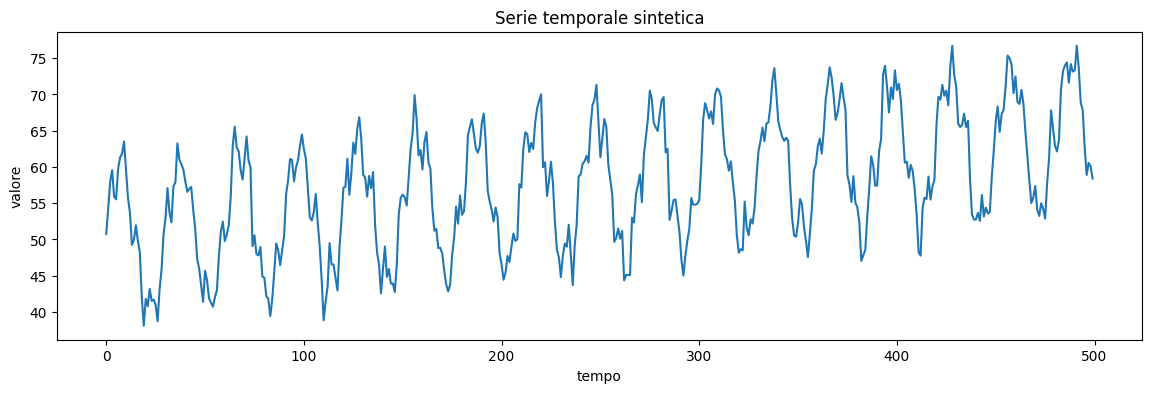

In [3]:
plt.figure(figsize=(14, 4))
plt.plot(ts["t"], ts["y"])
plt.title("Serie temporale sintetica")
plt.xlabel("tempo")
plt.ylabel("valore")
plt.show()


# 2) STL — Decomposizione della serie

**STL** = Seasonal-Trend decomposition using Loess

Idea:
- scomponiamo la serie in **trend**, **stagionalità** e **residuo**
- usiamo STL per capire meglio la struttura della serie


In [4]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts["y"], period=30, robust=True)
res = stl.fit()

ts["trend_stl"] = res.trend
ts["seasonal_stl"] = res.seasonal
ts["resid_stl"] = res.resid

ts.head()


,t,y,trend_stl,seasonal_stl,resid_stl
0,0,50.745071,50.224615,0.710358,-0.189902
1,1,54.247215,50.226500,4.575252,-0.554537
2,2,58.023683,50.228803,5.376640,2.418240
3,3,59.554049,50.231555,6.914125,2.408369
4,4,55.898567,50.234755,6.643108,-0.979296


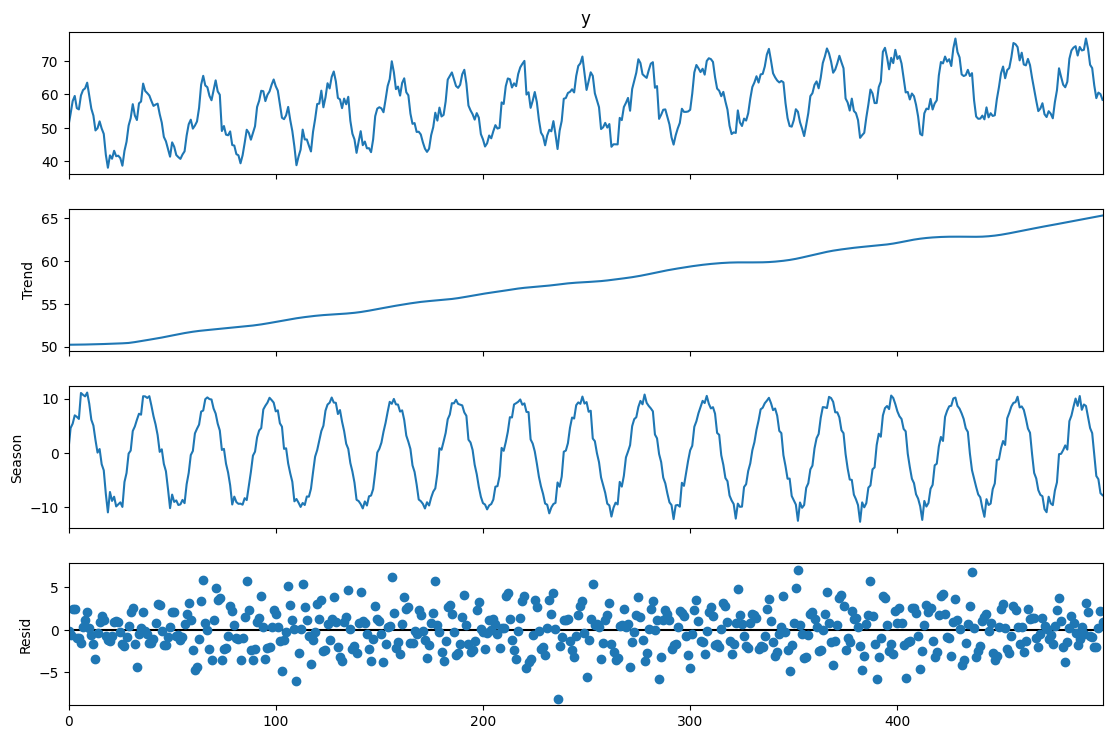

In [5]:
fig = res.plot()
fig.set_size_inches(12, 8)
plt.show()


# 3) ARIMA

**ARIMA** sta per:
- **AR** = AutoRegressive
- **I** = Integrated
- **MA** = Moving Average

## Interpretazione intuitiva
- AR: uso il passato della serie
- I: differenzio la serie per renderla più stabile
- MA: modello la struttura dell'errore residuo


In [6]:
train_size = int(len(ts) * 0.8)
train = ts.iloc[:train_size].copy()
test = ts.iloc[train_size:].copy()

len(train), len(test)


(400, 100)

In [8]:
from statsmodels.tsa.arima.model import ARIMA


arima_model = ARIMA(train["y"], order=(2, 1, 2))
arima_fit = arima_model.fit()

forecast = arima_fit.forecast(steps=len(test))

test["pred_arima"] = forecast.values

mae_arima = mean_absolute_error(test["y"], test["pred_arima"])
rmse_arima = mean_squared_error(test["y"], test["pred_arima"]) ** 0.5

mae_arima, rmse_arima


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(10.191750775381033, 12.325959619775986)

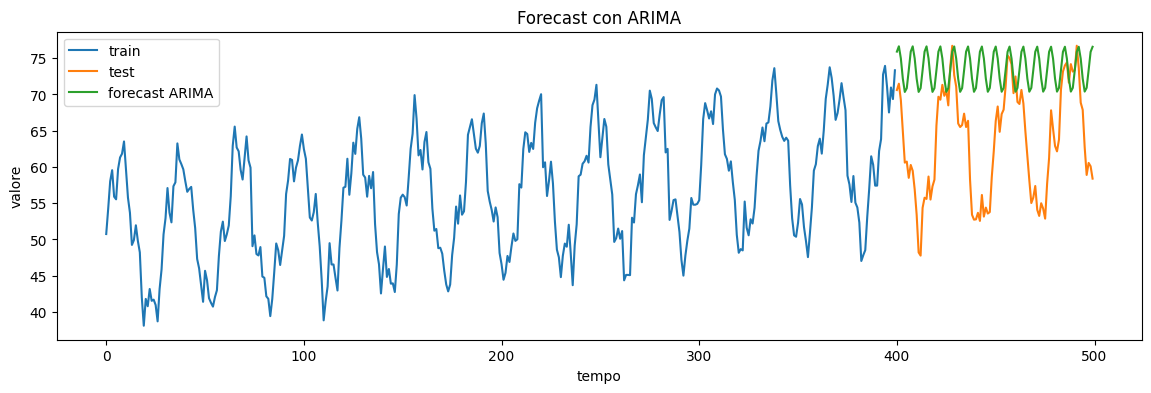

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(train["t"], train["y"], label="train")
plt.plot(test["t"], test["y"], label="test")
plt.plot(test["t"], test["pred_arima"], label="forecast ARIMA")
plt.title("Forecast con ARIMA")
plt.xlabel("tempo")
plt.ylabel("valore")
plt.legend()
plt.show()


In [10]:
train_deseasoned = train["y"] - train["seasonal_stl"]

arima_model = ARIMA(train_deseasoned, order=(2, 1, 2))
arima_fit = arima_model.fit()

# Forecast della componente destagionalizzata
forecast_deseasoned = arima_fit.forecast(steps=len(test))

# Ricostruiamo la stagionalità ripetendo l'ultimo ciclo noto (periodo 30)
last_season = train["seasonal_stl"].values[-30:]
seasonal_forecast = np.tile(last_season, int(np.ceil(len(test) / 30)))[:len(test)]

# Forecast finale = trend+residuo predetti + stagionalità ripetuta
test["pred_arima"] = forecast_deseasoned.values + seasonal_forecast

mae_arima = mean_absolute_error(test["y"], test["pred_arima"])
rmse_arima = mean_squared_error(test["y"], test["pred_arima"]) ** 0.5

mae_arima, rmse_arima

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(2.3072442049084647, 2.7971266947697706)

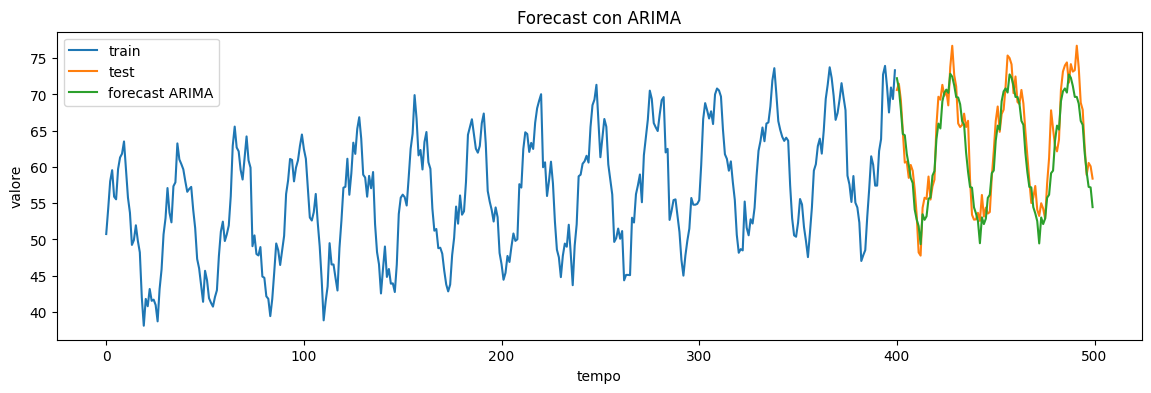

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(train["t"], train["y"], label="train")
plt.plot(test["t"], test["y"], label="test")
plt.plot(test["t"], test["pred_arima"], label="forecast ARIMA")
plt.title("Forecast con ARIMA")
plt.xlabel("tempo")
plt.ylabel("valore")
plt.legend()
plt.show()

# 4) Prophet

**Prophet** è un modello additivo che rappresenta:
- trend
- stagionalità
- eventualmente eventi

È spesso comodo quando vogliamo una modellazione leggibile di trend e stagionalità.


In [12]:
dates = pd.date_range("2023-01-01", periods=len(ts), freq="D")
ts_prophet = pd.DataFrame({
    "ds": dates,
    "y": ts["y"].values
})

train_p = ts_prophet.iloc[:train_size].copy()
test_p = ts_prophet.iloc[train_size:].copy()

ts_prophet.head()


,ds,y
0,2023-01-01,50.745071
1,2023-01-02,54.247215
2,2023-01-03,58.023683
3,2023-01-04,59.554049
4,2023-01-05,55.898567


In [13]:
try:
    from prophet import Prophet
    prophet_available = True
except Exception as e:
    prophet_available = False
    print("Prophet non disponibile. Installa con: pip install prophet")
    print("Errore:", e)


In [14]:
if prophet_available:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False
    )
    m.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    m.fit(train_p)

    future = ts_prophet[["ds"]].copy()
    forecast = m.predict(future)

    ts_prophet["yhat"] = forecast["yhat"].values
    test_p = test_p.merge(ts_prophet[["ds", "yhat"]], on="ds", how="left")

    mae_prophet = mean_absolute_error(test_p["y"], test_p["yhat"])
    rmse_prophet = mean_squared_error(test_p["y"], test_p["yhat"]) ** 0.5

    print("MAE Prophet:", round(mae_prophet, 3))
    print("RMSE Prophet:", round(rmse_prophet, 3))
else:
    print("Prophet non disponibile nell'ambiente.")


MAE Prophet: 5.512
RMSE Prophet: 6.286


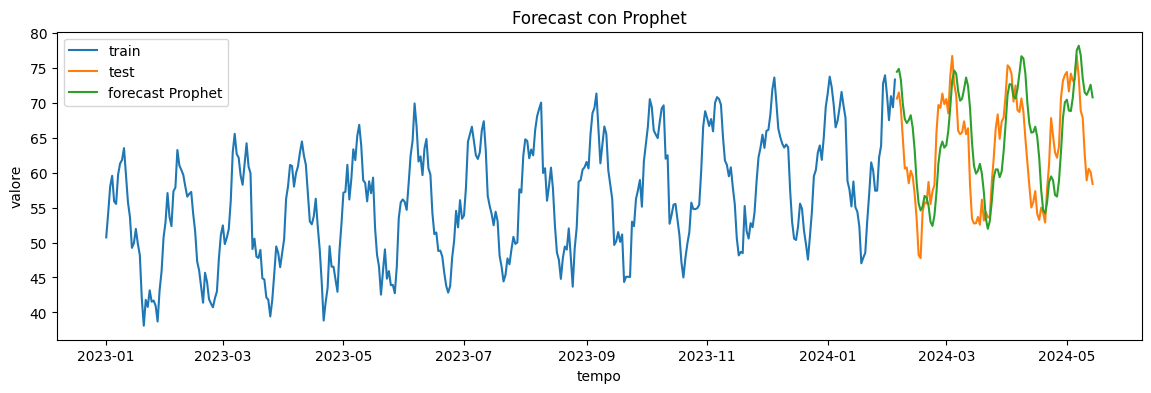

In [15]:
if prophet_available:
    plt.figure(figsize=(14, 4))
    plt.plot(train_p["ds"], train_p["y"], label="train")
    plt.plot(test_p["ds"], test_p["y"], label="test")
    plt.plot(test_p["ds"], test_p["yhat"], label="forecast Prophet")
    plt.title("Forecast con Prophet")
    plt.xlabel("tempo")
    plt.ylabel("valore")
    plt.legend()
    plt.show()


# 5) Forecasting come problema supervisionato: lag features + regressione

Qui trasformiamo la serie in un dataset tabellare usando:
- lag_1, lag_2, lag_3, lag_7, lag_14
- rolling mean
- rolling std

In questo modo una regressione può essere usata per forecasting.


In [16]:
df_sup = ts.copy()

for lag in [1, 2, 3, 7, 14]:
    df_sup[f"lag_{lag}"] = df_sup["y"].shift(lag)

df_sup["roll_mean_7"] = df_sup["y"].shift(1).rolling(7).mean()
df_sup["roll_std_7"] = df_sup["y"].shift(1).rolling(7).std()
df_sup["day_mod_7"] = df_sup["t"] % 7
df_sup["day_mod_30"] = df_sup["t"] % 30

df_sup = df_sup.dropna().reset_index(drop=True)
df_sup.head()


,t,y,trend_stl,seasonal_stl,resid_stl,lag_1,lag_2,lag_3,lag_7,lag_14,roll_mean_7,roll_std_7,day_mod_7,day_mod_30
0,14,49.911740,50.288015,0.031466,-0.407741,49.241952,53.676012,55.761202,61.306371,50.745071,57.842572,5.143434,0,14
1,15,51.952063,50.295087,0.691935,0.965041,49.911740,49.241952,53.676012,61.826502,54.247215,56.214768,5.643306,1,15
2,16,49.806420,50.302444,-2.121280,1.625256,51.952063,49.911740,49.241952,63.519189,58.023683,54.804134,5.225439,2,16
3,17,48.215656,50.310097,-3.232737,1.138295,49.806420,51.952063,49.911740,59.566779,59.554049,52.845167,3.785794,3,17
4,18,41.998460,50.318041,-7.575788,-0.743792,48.215656,49.806420,51.952063,55.761202,55.898567,51.223578,2.703049,4,18


In [17]:
feature_cols = [c for c in df_sup.columns if c not in ["y"]]
X = df_sup[feature_cols]
y_sup = df_sup["y"]

split_idx = int(len(df_sup) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_sup.iloc[:split_idx], y_sup.iloc[split_idx:]

X_train.shape, X_test.shape


((388, 13), (98, 13))

In [18]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
pred_lin = linreg.predict(X_test)

mae_lin = mean_absolute_error(y_test, pred_lin)
rmse_lin = mean_squared_error(y_test, pred_lin) ** 0.5

mae_lin, rmse_lin


(5.914180709790957e-13, 5.959726765840877e-13)

In [19]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf) ** 0.5

mae_rf, rmse_rf


(1.934052457084882, 2.4119956784090064)

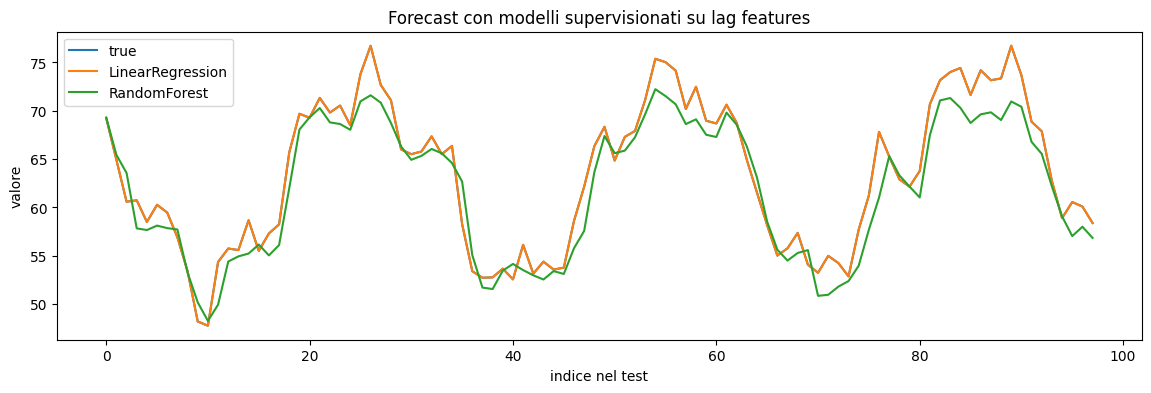

In [20]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values, label="true")
plt.plot(pred_lin, label="LinearRegression")
plt.plot(pred_rf, label="RandomForest")
plt.title("Forecast con modelli supervisionati su lag features")
plt.xlabel("indice nel test")
plt.ylabel("valore")
plt.legend()
plt.show()


In [21]:
results_tabular = pd.DataFrame({
    "model": ["ARIMA", "Prophet" if "mae_prophet" in globals() else "Prophet (n.d.)", "LinearRegression", "RandomForest"],
    "MAE": [mae_arima, mae_prophet if "mae_prophet" in globals() else np.nan, mae_lin, mae_rf],
    "RMSE": [rmse_arima, rmse_prophet if "rmse_prophet" in globals() else np.nan, rmse_lin, rmse_rf]
})
results_tabular


,model,MAE,RMSE
0,ARIMA,2.307244e+00,2.797127e+00
1,Prophet,5.511562e+00,6.285624e+00
2,LinearRegression,5.914181e-13,5.959727e-13
3,RandomForest,1.934052e+00,2.411996e+00


# 6) LSTM

Adesso passiamo a un modello sequenziale.

## Idea intuitiva
Nei modelli con lag features siamo noi a dire al modello quali pezzi del passato guardare.  
Con una **LSTM** vogliamo che il modello impari una rappresentazione temporale più flessibile.


In [22]:
from sklearn.preprocessing import MinMaxScaler

series = ts["y"].values.reshape(-1, 1)

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

window = 20

X_seq = []
y_seq = []

for i in range(window, len(series_scaled)):
    X_seq.append(series_scaled[i-window:i, 0])
    y_seq.append(series_scaled[i, 0])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

split_seq = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

X_train_seq.shape, X_test_seq.shape


((384, 20, 1), (96, 20, 1))

In [23]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    tf_available = True
except Exception as e:
    tf_available = False
    print("TensorFlow non disponibile. Installa con: pip install tensorflow")
    print("Errore:", e)


In [24]:
if tf_available:
    model = Sequential([
        LSTM(32, input_shape=(X_train_seq.shape[1], 1)),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    pred_lstm_scaled = model.predict(X_test_seq, verbose=0)

    pred_lstm = scaler.inverse_transform(pred_lstm_scaled)
    y_test_inv = scaler.inverse_transform(y_test_seq.reshape(-1, 1))

    mae_lstm = mean_absolute_error(y_test_inv, pred_lstm)
    rmse_lstm = mean_squared_error(y_test_inv, pred_lstm) ** 0.5

    print("MAE LSTM:", round(mae_lstm, 3))
    print("RMSE LSTM:", round(rmse_lstm, 3))
else:
    print("TensorFlow non disponibile nell'ambiente.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE LSTM: 4.816
RMSE LSTM: 5.566


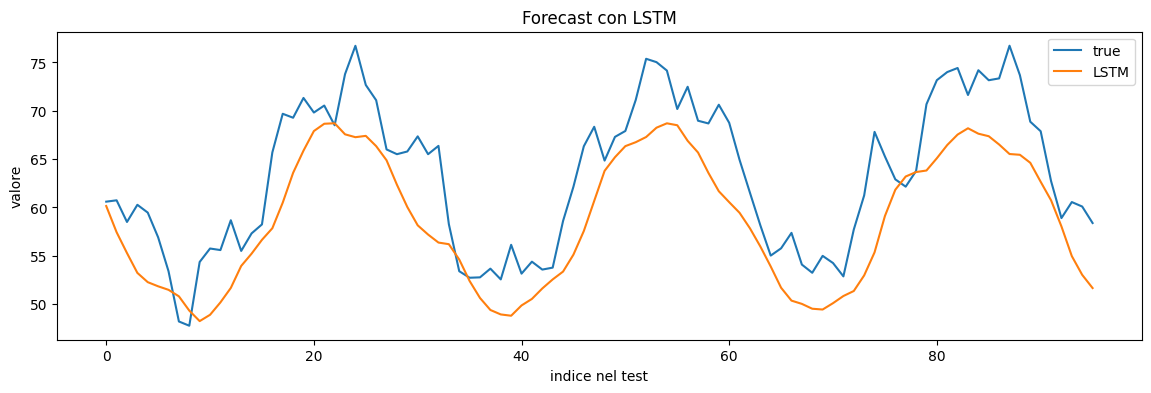

In [25]:
if tf_available:
    plt.figure(figsize=(14, 4))
    plt.plot(y_test_inv, label="true")
    plt.plot(pred_lstm, label="LSTM")
    plt.title("Forecast con LSTM")
    plt.xlabel("indice nel test")
    plt.ylabel("valore")
    plt.legend()
    plt.show()


In [26]:
if tf_available:
    results_all = results_tabular.copy()
    results_all.loc[len(results_all)] = ["LSTM", mae_lstm, rmse_lstm]
    results_all
else:
    results_tabular


# 7) Cenno ai dati sintetici — CTGAN

## Perché può servire generare dati sintetici?
- il dataset è piccolo
- i dati sono sensibili e non facilmente condivisibili
- vogliamo simulare scenari
- vogliamo testare pipeline senza esporre dati reali

## Che cos'è CTGAN?
**CTGAN** = Conditional Tabular GAN

È una GAN pensata per **dati tabellari**, non specificamente per il forecasting.


In [27]:
tab_for_ctgan = df_sup.copy()
tab_for_ctgan.head()


,t,y,trend_stl,seasonal_stl,resid_stl,lag_1,lag_2,lag_3,lag_7,lag_14,roll_mean_7,roll_std_7,day_mod_7,day_mod_30
0,14,49.911740,50.288015,0.031466,-0.407741,49.241952,53.676012,55.761202,61.306371,50.745071,57.842572,5.143434,0,14
1,15,51.952063,50.295087,0.691935,0.965041,49.911740,49.241952,53.676012,61.826502,54.247215,56.214768,5.643306,1,15
2,16,49.806420,50.302444,-2.121280,1.625256,51.952063,49.911740,49.241952,63.519189,58.023683,54.804134,5.225439,2,16
3,17,48.215656,50.310097,-3.232737,1.138295,49.806420,51.952063,49.911740,59.566779,59.554049,52.845167,3.785794,3,17
4,18,41.998460,50.318041,-7.575788,-0.743792,48.215656,49.806420,51.952063,55.761202,55.898567,51.223578,2.703049,4,18


In [29]:
try:
    from ctgan import CTGAN
    ctgan_available = True
except Exception as e:
    ctgan_available = False
    print("CTGAN non disponibile. Installa con: pip install ctgan")
    print("Errore:", e)


In [30]:
if ctgan_available:
    model_ctgan = CTGAN(epochs=50, verbose=False)
    model_ctgan.fit(tab_for_ctgan)

    synthetic_samples = model_ctgan.sample(5)
    synthetic_samples
else:
    print("CTGAN non disponibile nell'ambiente.")


### Commento finale su CTGAN
CTGAN è utile per **dati tabellari sintetici**.  
Se vogliamo generare vere sequenze temporali sintetiche realistiche, il problema è ancora più delicato e spesso richiede modelli specifici per serie temporali.


# 8) Conclusioni finali

## Cosa abbiamo visto
- **STL** per leggere la struttura della serie
- **ARIMA** come modello classico autoregressivo
- **Prophet** come modello additivo per trend e stagionalità
- **regressione con lag features** come forecasting supervisionato
- **LSTM** come modello sequenziale più espressivo
- **CTGAN** come apertura sul tema dei dati sintetici tabellari

## Messaggi chiave
1. nel forecasting il tempo conta e impedisce split casuali
2. non esiste un solo modello corretto: ogni approccio fa assunzioni diverse
3. una baseline semplice può essere molto forte
4. il deep learning non sostituisce il ragionamento sul dato
5. i dati sintetici sono utili, ma vanno usati con cautela


# 9) Domande finali

1. Che cosa aggiunge STL rispetto al guardare solo la serie grezza?
2. In che senso ARIMA e Prophet fanno assunzioni diverse sulla serie?
3. Perché una regressione lineare non può fare forecasting senza lag features?
4. Qual è la differenza tra un modello su lag features e una LSTM?
5. Perché CTGAN non è, di per sé, un modello di forecasting?
6. In quali casi usereste un modello semplice, e in quali provereste una LSTM?
